## Basic routine

In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

In [2]:
import sys
sys.path.append('../..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA, SLSQP
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit.primitives import Sampler
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Statevector
from sklearn.metrics import r2_score
import pickle

In [3]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [4]:
main_seq = "YYDPETGTWY" # 10 AA chingolin
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op()
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))
print(qubit_op)

Number of qubits:  66
Number of terms:  29227
SparsePauliOp(['...'],
              coeffs=[ 3.425525e+02+0.j,  6.278750e+00+0.j,  8.795000e+00+0.j, ...,
 -1.881250e-01+0.j, -1.881250e-01+0.j, -1.881250e-01+0.j])


In [5]:
import pandas as pd

def qubit_op_to_df(data):
    # Create a DataFrame from the list, explicitly handling complex numbers and Paulis
    df = pd.DataFrame(data, columns=['Paulis', 'Coefficient'])
    
    # Convert complex number to its real part
    df['Coefficients'] = df['Coefficient'].apply(lambda x: x.real)
    
    # Drop the original 'Coefficient' column as it's no longer needed
    df.drop('Coefficient', axis=1, inplace=True)
    
    # Calculate the weight
    df['Weight'] = df['Paulis'].apply(lambda s: s.count('Z'))
    
    # Calculate the locality
    def count_adjacent_zs(s):
        count = 0
        in_z_sequence = False
        for char in s:
            if char == 'Z':
                if not in_z_sequence:
                    in_z_sequence = True
                    count += 1
            else:
                in_z_sequence = False
        return count
    
    df['Locality'] = df['Paulis'].apply(count_adjacent_zs)
    
    return df

In [6]:
df1 = qubit_op_to_df(qubit_op.to_list(array=False))

df1

,Paulis,Coefficients,Weight,Locality
0,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,342.552500,0,0
1,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,6.278750,2,1
2,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,8.795000,3,2
3,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,8.795000,3,1
4,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,-8.795000,2,1
...,...,...,...,...
29222,ZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZIIZZZII...,0.188125,7,3
29223,ZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIZZZII...,0.188125,5,3
29224,ZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIZIZZZII...,-0.188125,7,4
29225,ZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIZZIZZZII...,-0.188125,7,4


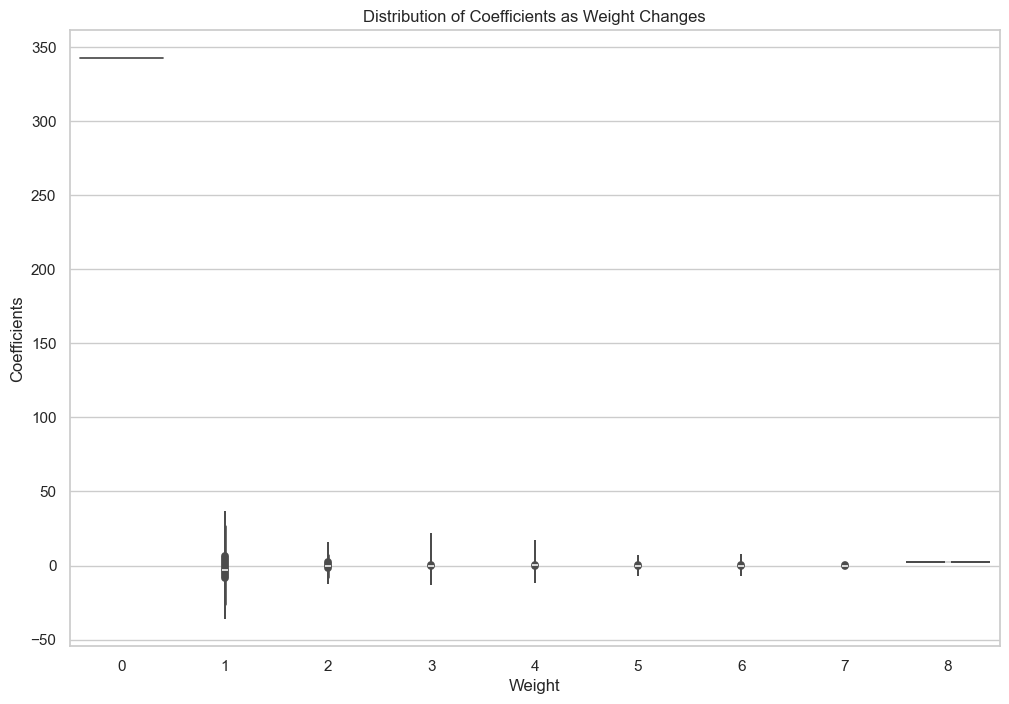

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_coefficients(df):
    # Set the aesthetic style of the plots
    sns.set_theme(style="whitegrid")

    # Create a violin plot to see the distribution of 'Coefficients' as 'Weight' changes
    plt.figure(figsize=(12, 8))
    sns.violinplot(x='Weight', y='Coefficients', data=df)

    # Adding title and labels
    plt.title('Distribution of Coefficients as Weight Changes')
    plt.xlabel('Weight')
    plt.ylabel('Coefficients')

    # Show the plot
    plt.show()

# Assuming df is your DataFrame from the previous steps
plot_coefficients(df1)


In [8]:
def truncate_terms_based_on_coefficient(df, n):
    # Filter out rows where weight is zero
    df_non_zero = df[df['Weight'] != 0]
    
    # Function to apply the filtering based on coefficient threshold
    def exclude_low_coefficients(group):
        avg = group['Coefficients'].mean()
        lower_threshold = avg * (1 - n / 100)
        return group[group['Coefficients'] >= lower_threshold]
    
    # Apply the filter to each weight group and reset index
    retained_df = df_non_zero.groupby('Weight').apply(exclude_low_coefficients).reset_index(drop=True)
    
    # Calculate how many terms were excluded
    terms_excluded = df_non_zero.groupby('Weight').size() - retained_df.groupby('Weight').size()
    
    # Return both the new dataframe and the count of excluded terms
    return retained_df, terms_excluded

In [9]:
df_trunc, truncated_terms = truncate_terms_based_on_coefficient(df1, 25)

df_trunc

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_19008\2595235653.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retained_df = df_non_zero.groupby('Weight').apply(exclude_low_coefficients).reset_index(drop=True)


,Paulis,Coefficients,Weight,Locality
0,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,26.60000,1,1
1,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,17.88000,1,1
2,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,11.92000,1,1
3,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,11.92000,1,1
4,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,15.48750,1,1
...,...,...,...,...
11202,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,2.34375,8,1
11203,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,2.34375,8,1
11204,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ...,2.34375,8,1
11205,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZZZZ...,2.34375,8,1


In [10]:
truncated_terms

Weight
1      34
2     316
3    2879
4    2752
5    7448
6    2210
7    2380
8       0
dtype: int64

In [11]:
from qiskit.quantum_info import SparsePauliOp

def create_sparse_pauli_op(df):
    # Extract tuples of (Pauli string, Coefficient) from the DataFrame
    pauli_list = list(zip(df['Paulis'], df['Coefficients']))
    
    # Create the SparsePauliOp from the list of tuples
    sparse_pauli_op = SparsePauliOp.from_list(pauli_list)
    
    return sparse_pauli_op

In [12]:
reduced_qubit_op = create_sparse_pauli_op(df_trunc)

In [13]:

from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.quantum_info import commutator

def mixer_op_x(n, theta: np.pi):
    # Theta = pi for standard X Pauli
    rx_terms = []
    for i in range(n):
        # Create a Pauli string with X on the i-th qubit and I on the others
        labels = ['I'] * n
        labels[i] = 'X'
        pauli_string = ''.join(labels)
        pauli_op = SparsePauliOp(Pauli(pauli_string), coeffs=[theta/2])
        rx_terms.append(pauli_op)
    mixer_hamiltonian = sum(rx_terms, start=SparsePauliOp.from_list([('I'*n, 0)]))
    return mixer_hamiltonian


def truncate_to_n_local(pauli_op, n, return_output=True):
    # Extract labels and coefficients
    labels = pauli_op.paulis.to_labels()
    coeffs = pauli_op.coeffs
    # Initialize list to collect the filtered terms
    filtered_labels = []
    filtered_coeffs = []
    
    # Filter terms to include only those with up to n non-identity operators ('X', 'Y', 'Z')
    for label, coeff in zip(labels, coeffs):
        non_identity_count = sum(1 for char in label if char != 'I')
        
        if non_identity_count <= n:
            filtered_labels.append(label)
            filtered_coeffs.append(coeff)
    
    # Construct the new SparsePauliOp if there are any valid terms
    if filtered_labels:
        truncated_terms = SparsePauliOp.from_list(list(zip(filtered_labels, filtered_coeffs)))
    else:
        # Return an empty operator if no terms meet the criteria
        truncated_terms = SparsePauliOp.from_list([('I' * pauli_op.num_qubits, 0)])
    
    # Optionally return the result
    if return_output:
        return truncated_terms
    else:
        # The output can be captured in a variable 'U_cd' for later use without being returned
        U_cd = truncated_terms
        # Optionally print or log the variable for verification or debugging
        # print("U_cd stored:", U_cd)
        pass

    
    # Optionally return the result
    if return_output:
        return truncated_terms
    else:
        # The output can be captured in a variable 'U_cd' for later use without being returned
        U_cd = truncated_terms
        # Optionally print or log the variable for verification or debugging
        # print("U_cd stored:", U_cd)
        pass


def calculate_commutator(hamiltonian, truncate: bool, order: int):
    mixer_op = mixer_op_x(hamiltonian.num_qubits, np.pi)  # Regular Pauli X mixer
    # Set up the Hamiltonians
    H_a = 0.5 * mixer_op + 0.5 * hamiltonian
    partial_H_a = -mixer_op + hamiltonian

    # Start with the first commutator
    current_commutator = commutator(H_a, partial_H_a).simplify()
    
    # Compute nested commutators up to the specified order
    for _ in range(order - 1):
        current_commutator = commutator(H_a, current_commutator).simplify()
    
    if truncate:
        # If truncation is needed, filter to two-local terms with specific Pauli characters
        final_hamiltonian = truncate_to_n_local(current_commutator, 2).simplify()
    else:
        # If no truncation is needed, use the final commutator result
        final_hamiltonian = current_commutator

    return final_hamiltonian

In [14]:
from qiskit.quantum_info import SparsePauliOp
from collections import Counter

def analyze_pauli_terms(pauli_op: SparsePauliOp):
    # Extract labels from the Pauli operator
    labels = pauli_op.paulis.to_labels()
    
    # Initialize a Counter to store occurrences of each Pauli term type
    term_types = Counter()
    
    # Iterate over each label and process
    # Skip the sorting to keep 'XZ' and 'ZX' distinct
    for label in labels:
        # Remove identity matrices, keep the order of non-identity Pauli matrices
        normalized_label = label.replace('I', '')
        if normalized_label == '':
            normalized_label = 'I'  # Include identity as a term if all are 'I'
        term_types[normalized_label] += 1
    
    # Return a dictionary of term types with their counts
    return dict(term_types)


In [15]:
analyze_pauli_terms(reduced_qubit_op)

{'Z': 25,
 'ZZ': 310,
 'ZZZ': 1855,
 'ZZZZ': 2719,
 'ZZZZZ': 2681,
 'ZZZZZZ': 2183,
 'ZZZZZZZ': 1428,
 'ZZZZZZZZ': 6}

In [16]:
truncated_qubit_op = truncate_to_n_local(qubit_op, 2)

In [17]:
analyze_pauli_terms(truncated_qubit_op)

{'I': 1, 'ZZ': 626, 'Z': 59}

In [18]:
dcd_hamiltonian = calculate_commutator(truncated_qubit_op, True, 2)
analyze_pauli_terms(dcd_hamiltonian)

{'Z': 59, 'ZZ': 626, 'YY': 626, 'X': 60, 'XZ': 626, 'ZX': 624}

In [19]:
from qiskit.quantum_info import SparsePauliOp, Pauli

def select_terms(dcd_hamiltonian, term_analysis, num_qubits, selection_mode):
    # Extract labels and coefficients
    labels = dcd_hamiltonian.paulis.to_labels()
    coeffs = dcd_hamiltonian.coeffs
    
    # Initialize variables for lowest count logic if needed
    if selection_mode == "two_local_min":
        lowest_count = float('inf')
        lowest_term_type = None
        for term, count in term_analysis.items():
            if len(term) == 2 and count < lowest_count:
                lowest_count = count
                lowest_term_type = term
    
    # Initialize a list to collect the selected terms with their coefficients
    selected_terms = []
    
    # Filter the terms based on the analysis
    for label, coeff in zip(labels, coeffs):
        # Remove identity and keep original order
        normalized_label = label.replace('I', '')

        # Select weight-1 terms where the count matches the number of qubits
        if normalized_label in term_analysis and len(normalized_label) == 1 and term_analysis[normalized_label] == num_qubits:
            selected_terms.append((label, coeff))
        
        # Select weight-2 terms based on the mode
        if len(normalized_label) == 2:
            if selection_mode == "two_local_min" and normalized_label == lowest_term_type:
                selected_terms.append((label, coeff))
            elif selection_mode == "linear":
                # Check if terms are adjacent non-trivially
                non_trivial_indices = [i for i, x in enumerate(label) if x != 'I']
                if len(non_trivial_indices) == 2 and abs(non_trivial_indices[0] - non_trivial_indices[1]) == 1:
                    selected_terms.append((label, coeff))

    # Return a new SparsePauliOp with the selected terms
    return SparsePauliOp.from_list(selected_terms)


In [20]:
dcd_selection_min = select_terms(dcd_hamiltonian, analyze_pauli_terms(dcd_hamiltonian), qubit_op.num_qubits, "two_local_min")
analyze_pauli_terms(dcd_selection_min)

{'ZX': 624}

In [21]:
dcd_selection_linear = select_terms(dcd_hamiltonian, analyze_pauli_terms(dcd_hamiltonian), qubit_op.num_qubits, "linear")
analyze_pauli_terms(dcd_selection_linear)

{'ZZ': 29, 'YY': 29, 'XZ': 29, 'ZX': 28}

In [28]:
dcd_selection_linear.paulis

PauliList(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYYIIIIII...',
           'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [22]:
from dcd_ansatz import dig_count_ansatz

dcd_ansatz = dig_count_ansatz(dcd_selection_linear)

In [29]:
dcd_ansatz.draw('mpl', fold=1)